In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from models import GestureClassifier

/home/david/miniconda3/envs/cvai/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
class HandGestureDataset(Dataset):
    def __init__(self, data_frame):
        self.data = data_frame
        
        # Extract features (landmarks) and labels
        feature_cols = [col for col in self.data.columns if col.startswith('landmark_')]
        self.X = self.data[feature_cols].values
        
        # Make sure labels are 0-indexed integers
        unique_labels = sorted(self.data['label'].unique())
        label_map = {label: i for i, label in enumerate(unique_labels)}
        self.y = np.array([label_map[label] for label in self.data['label'].values])
        self.label_map = label_map
        self.label_map_inverse = {v: k for k, v in label_map.items()}
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        features = torch.tensor(self.X[idx], dtype=torch.float)
        label = torch.tensor(self.y[idx], dtype=torch.long)  # Must be Long for CrossEntropyLoss
        return features, label

In [3]:
def load_and_prepare_data(file_path, test_size=0.2):
    """Load data from parquet file and prepare train/test splits"""
    
    # Load the data
    df = pd.read_parquet(file_path)
    
    # Create dataset
    dataset = HandGestureDataset(df)
    
    # Split into train and test sets
    train_size = int((1 - test_size) * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    return train_dataset, test_dataset

In [4]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=100):
    """Train the neural network model"""
    
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Evaluation phase
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_acc)
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, '
                 f'Train Loss: {train_losses[-1]:.4f}, '
                 f'Train Acc: {train_accuracies[-1]:.4f}, '
                 f'Test Loss: {test_losses[-1]:.4f}, '
                 f'Test Acc: {test_accuracies[-1]:.4f}')
    
    return train_losses, test_losses, train_accuracies, test_accuracies

In [5]:
def evaluate_model(model, test_loader, device):
    """Evaluate the trained model"""
    
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))
    
    return cm, all_preds, all_labels

In [6]:
def plot_results(train_losses, test_losses, train_accuracies, test_accuracies, cm):
    """Plot training curves and confusion matrix and return figures"""
    
    # Create figure for training curves
    curves_fig = plt.figure(figsize=(12, 4))
    
    # Plot loss curves
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Test Loss')
    
    # Plot accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Test Accuracy')
    
    plt.tight_layout()
    
    # Create figure for confusion matrix
    cm_fig = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    return curves_fig, cm_fig

In [7]:
def save_model(model, file_path):
    """Save the trained model"""
    torch.save(model.state_dict(), file_path)
    print(f"Model saved to {file_path}")

In [8]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [9]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
# Load and prepare data
file_path = 'hand_landmarks.parquet'
train_dataset, test_dataset = load_and_prepare_data(file_path)

print(f"Loaded {len(train_dataset)} training samples and {len(test_dataset)} testing samples.")

Loaded 480 training samples and 120 testing samples.


In [11]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get input size from the first item in the dataset
input_size = train_dataset[0][0].shape[0]

# Get the unique classes from your data
all_dataset = pd.read_parquet(file_path)
num_classes = len(all_dataset['label'].unique())

print(f"Input size: {input_size}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Input size: 42
Number of classes: 6
Training samples: 480
Testing samples: 120


In [12]:
# Create model
model = GestureClassifier(input_size=input_size, hidden_size=128, num_classes=num_classes, dropout_prob=0.2)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
# Train the model
print("Starting training...")
results = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=100
)
train_losses, test_losses, train_accuracies, test_accuracies = results

Starting training...
Epoch 10/100, Train Loss: 0.0536, Train Acc: 0.9958, Test Loss: 0.0184, Test Acc: 1.0000
Epoch 20/100, Train Loss: 0.0181, Train Acc: 0.9979, Test Loss: 0.0028, Test Acc: 1.0000
Epoch 30/100, Train Loss: 0.0166, Train Acc: 0.9979, Test Loss: 0.0019, Test Acc: 1.0000
Epoch 40/100, Train Loss: 0.0101, Train Acc: 0.9979, Test Loss: 0.0015, Test Acc: 1.0000
Epoch 50/100, Train Loss: 0.0158, Train Acc: 0.9979, Test Loss: 0.0023, Test Acc: 1.0000
Epoch 60/100, Train Loss: 0.0144, Train Acc: 0.9979, Test Loss: 0.0017, Test Acc: 1.0000
Epoch 70/100, Train Loss: 0.0123, Train Acc: 0.9979, Test Loss: 0.0020, Test Acc: 1.0000
Epoch 80/100, Train Loss: 0.0119, Train Acc: 0.9979, Test Loss: 0.0010, Test Acc: 1.0000
Epoch 90/100, Train Loss: 0.0115, Train Acc: 0.9979, Test Loss: 0.0011, Test Acc: 1.0000
Epoch 100/100, Train Loss: 0.0105, Train Acc: 0.9979, Test Loss: 0.0010, Test Acc: 1.0000



Evaluating model...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        18
           5       1.00      1.00      1.00        16

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



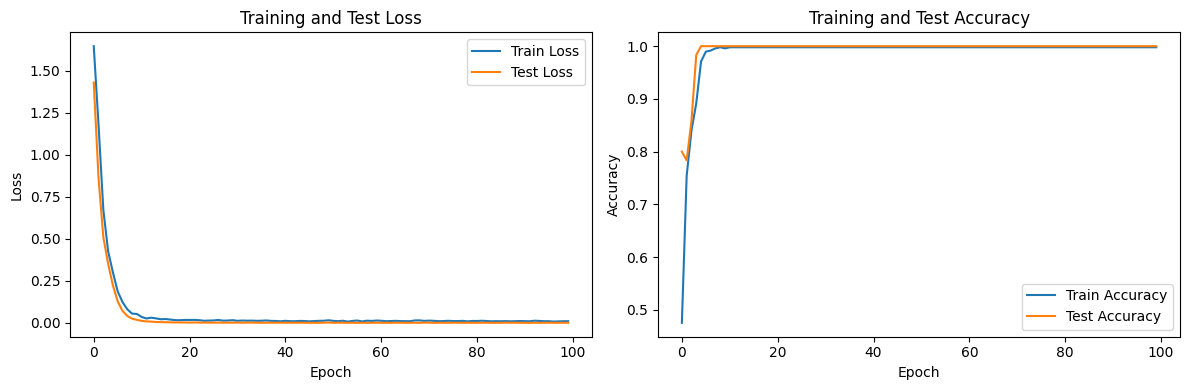

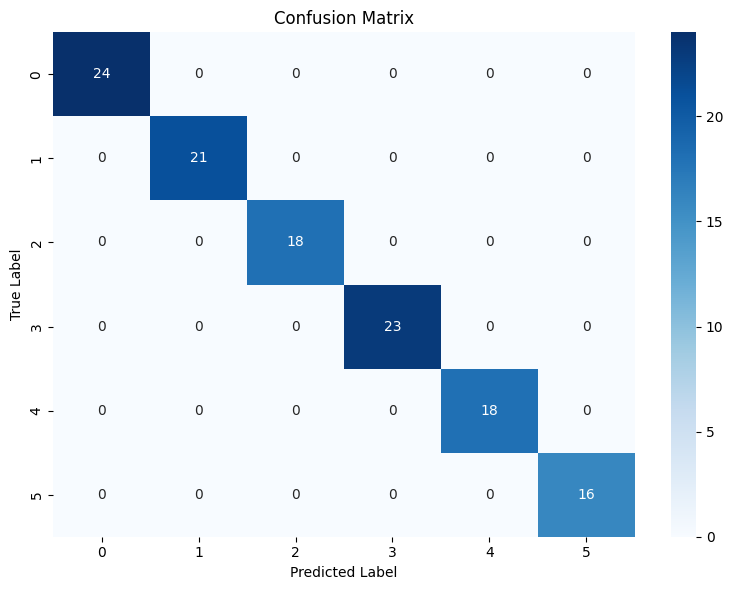

In [14]:
# Evaluate model
print("\nEvaluating model...")
cm, all_preds, all_labels = evaluate_model(model, test_loader, device)

curves_fig, cm_fig = plot_results(train_losses, test_losses, train_accuracies, test_accuracies, cm)

In [15]:
model_save_path = "model_checkpoints/gesture_classifier.pth"
save_model(model, model_save_path)

Model saved to model_checkpoints/gesture_classifier.pth
